<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/TimeXer/run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
from google.colab import userdata

user = "Maziger"
repo = "Laksegate-master-thesis"

# remove local directory if it already exists
if os.path.isdir(repo):
    !rm -rf {repo}

!git clone https://github.com/{user}/{repo}.git
%cd Laksegate-master-thesis/

Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 378, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 378 (delta 31), reused 24 (delta 10), pack-reused 306 (from 2)
Receiving objects: 100% (378/378), 55.30 MiB | 13.22 MiB/s, done.
Resolving deltas: 100% (200/200), done.
/content/Laksegate-master-thesis/POC/TimeXer/Laksegate-master-thesis


In [7]:
!ls

POC  README.md


In [8]:
%cd POC
%cd TimeXer

/content/Laksegate-master-thesis/POC/TimeXer/Laksegate-master-thesis/POC
/content/Laksegate-master-thesis/POC/TimeXer/Laksegate-master-thesis/POC/TimeXer


In [9]:
!pip install -q torch pandas scikit-learn matplotlib tqdm einops patool sktime reformer-pytorch

In [ ]:
import sys, random
import numpy as np
import torch

sys.path.insert(0, '.')

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

import argparse
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast

args = argparse.Namespace(
    task_name='long_term_forecast',
    is_training=1,
    model_id='DE_168_24',
    model='TimeXer',
    data='custom',
    root_path='./dataset/EPF/',
    data_path='DE.csv',
    features='MS',
    target='OT',
    freq='h',
    checkpoints='./checkpoints/',
    seq_len=168,
    label_len=48,
    pred_len=24,
    patch_len=24,
    e_layers=1,
    enc_in=3,
    dec_in=3,
    c_out=1,
    d_model=512,
    n_heads=8,
    d_layers=1,
    d_ff=2048,
    batch_size=4,
    train_epochs=10,
    patience=3,
    learning_rate=0.0001,
    des='Timexer-MS',
    loss='MSE',
    lradj='type1',
    itr=1,
    num_workers=2,
    use_amp=False,
    use_norm=1,
    inverse=False,
    embed='timeF',
    activation='gelu',
    factor=1,
    dropout=0.1,
    distil=True,
    output_attention=False,
    moving_avg=25,
    top_k=5,
    num_kernels=6,
    expand=2,
    d_conv=4,
    seg_len=48,
    p_hidden_dims=[128, 128],
    p_hidden_layers=2,
    augmentation_ratio=0,
    use_dtw=False,
    seasonal_patterns='Monthly',
    mask_rate=0.25,
    anomaly_ratio=0.25,
    channel_independence=1,
    decomp_method='moving_avg',
    down_sampling_layers=0,
    down_sampling_window=1,
    down_sampling_method=None,
    use_gpu=True,
    gpu=0,
    use_multi_gpu=False,
    devices='0',
)

args.use_gpu = torch.cuda.is_available()
print(f"GPU available: {args.use_gpu}")
if args.use_gpu:
    print(torch.cuda.get_device_name(0))

exp = Exp_Long_Term_Forecast(args)

setting = (f"{args.task_name}_{args.model_id}_{args.model}_{args.data}_"
           f"ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_"
           f"dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_"
           f"df{args.d_ff}_expand{args.expand}_dc{args.d_conv}_fc{args.factor}_"
           f"eb{args.embed}_dt{args.distil}_{args.des}_0")

print(f'>>>>>>>start training: {setting}')
exp.train(setting)

print(f'>>>>>>>testing: {setting}')
exp.test(setting)
torch.cuda.empty_cache()


GPU available: True
Tesla T4
Use GPU: cuda:0
>>>>>>>start training: long_term_forecast_DE_168_24_TimeXer_custom_ftMS_sl168_ll48_pl24_dm512_nh8_el1_dl1_df2048_expand2_dc4_fc1_ebtimeF_dtTrue_Timexer-MS_0
train 36500
val 5219
test 10460
	iters: 100, epoch: 1 | loss: 1.5085258
	speed: 0.0531s/iter; left time: 4844.0731s
	iters: 200, epoch: 1 | loss: 0.3349008
	speed: 0.0119s/iter; left time: 1086.1041s
	iters: 300, epoch: 1 | loss: 1.3695457
	speed: 0.0122s/iter; left time: 1113.1136s
	iters: 400, epoch: 1 | loss: 0.3256595
	speed: 0.0151s/iter; left time: 1371.1944s
	iters: 500, epoch: 1 | loss: 0.6055267
	speed: 0.0140s/iter; left time: 1270.2531s
	iters: 600, epoch: 1 | loss: 0.4027645
	speed: 0.0113s/iter; left time: 1021.9189s
	iters: 700, epoch: 1 | loss: 0.6246306
	speed: 0.0111s/iter; left time: 1003.3954s
	iters: 800, epoch: 1 | loss: 0.2040088
	speed: 0.0112s/iter; left time: 1015.6488s
	iters: 900, epoch: 1 | loss: 0.6921748
	speed: 0.0135s/iter; left time: 1219.6947s
	iters: 10

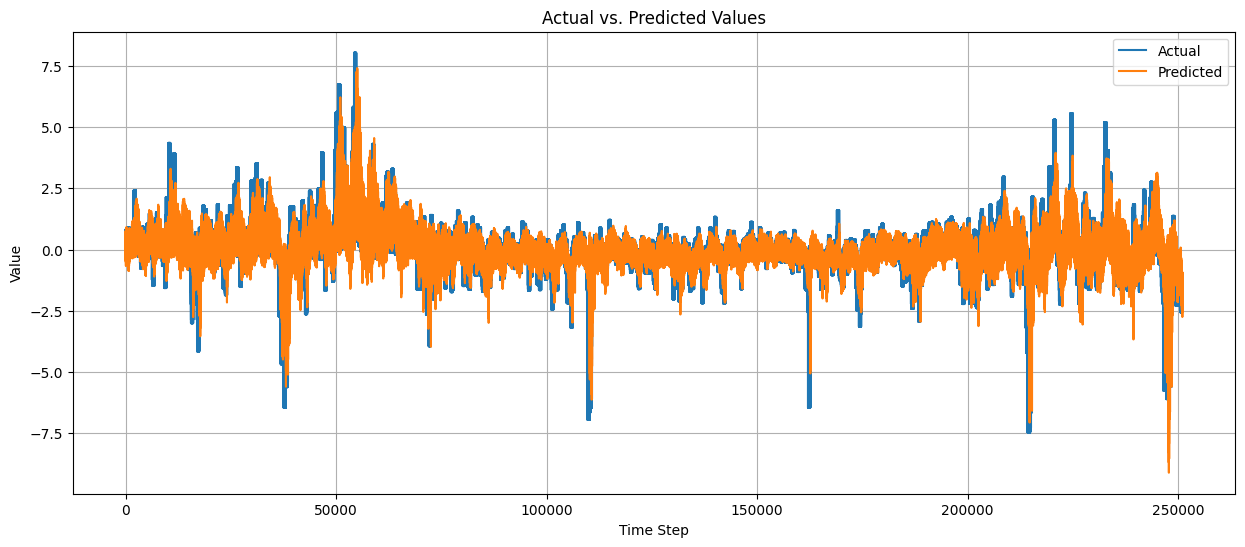

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

# The 'setting' variable is already defined in the kernel state from the previous run

# Construct the path to the results directory. The current directory is TimeXer.
# The results folder is at Laksegate-master-thesis/results.
results_dir = os.path.join('./results', setting)

# Load true and predicted values
true_values = np.load(os.path.join(results_dir, 'true.npy'))
predicted_values = np.load(os.path.join(results_dir, 'pred.npy'))

# Assuming the shape is (num_samples, seq_len, num_features)
# For plotting, let's take the first feature and flatten or just use a segment.
# We need to decide which part of the sequence to plot. Let's plot the first sample's prediction.

# For simplicity, let's plot the first series (index 0) and the first feature (index 0)
# You might need to adjust indices based on your specific data structure.
# Reshape if necessary: (batch_size, sequence_length, features) -> (total_elements,)

# Let's plot the last prediction length of the first sample for comparison.
# The `pred_len` variable from args (24) defines how many steps were predicted.

# Reshape true and predicted values to (N, L, C) -> (N * L, C) if needed, or pick one series.
# The output from Exp_Long_Term_Forecast test method usually gives (num_test_samples, pred_len, c_out)
# Let's assume true_values and predicted_values are of shape (num_samples, pred_len, c_out)

# Take the first sample and the first output channel (c_out=1 in args, so only one channel)
# Reshape to (num_samples * pred_len,) for plotting

true_flat = true_values[:, :, 0].reshape(-1)
predicted_flat = predicted_values[:, :, 0].reshape(-1)

# Turn off interactive mode to prevent potential double-display issues
plt.ioff()

fig = plt.figure(figsize=(15, 6))
plt.plot(true_flat, label='Actual')
plt.plot(predicted_flat, label='Predicted')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Explicitly display the figure object
display(fig)

# Close the figure to free up memory after displaying
plt.close(fig)


In [10]:
import sys, random
import numpy as np
import torch

sys.path.insert(0, '.')

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

import argparse
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast

args = argparse.Namespace(
    task_name='long_term_forecast',
    is_training=1,
    model_id='DE_Ensemble_168_24',
    model='TimeXer',
    data='custom',
    root_path='./dataset/EPF/',
    data_path='Forecasts_DE_DNN_LEAR_ensembles.csv',
    features='MS',
    target='Real price',
    freq='h',
    checkpoints='./checkpoints/',
    seq_len=168,
    label_len=48,
    pred_len=24,
    patch_len=24,
    e_layers=1,
    enc_in=11,
    dec_in=11,
    c_out=1,
    d_model=512,
    n_heads=8,
    d_layers=1,
    d_ff=2048,
    batch_size=4,
    train_epochs=10,
    patience=3,
    learning_rate=0.0001,
    des='Timexer-MS-Ensemble',
    loss='MSE',
    lradj='type1',
    itr=1,
    num_workers=2,
    use_amp=False,
    use_norm=1,
    inverse=False,
    embed='timeF',
    activation='gelu',
    factor=1,
    dropout=0.1,
    distil=True,
    output_attention=False,
    moving_avg=25,
    top_k=5,
    num_kernels=6,
    expand=2,
    d_conv=4,
    seg_len=48,
    p_hidden_dims=[128, 128],
    p_hidden_layers=2,
    augmentation_ratio=0,
    use_dtw=False,
    seasonal_patterns='Monthly',
    mask_rate=0.25,
    anomaly_ratio=0.25,
    channel_independence=1,
    decomp_method='moving_avg',
    down_sampling_layers=0,
    down_sampling_window=1,
    down_sampling_method=None,
    use_gpu=True,
    gpu=0,
    use_multi_gpu=False,
    devices='0',
)

args.use_gpu = torch.cuda.is_available()
print(f"GPU available: {args.use_gpu}")
if args.use_gpu:
    print(torch.cuda.get_device_name(0))

exp = Exp_Long_Term_Forecast(args)

setting_ensemble = (f"{args.task_name}_{args.model_id}_{args.model}_{args.data}_"
                    f"ft{args.features}_sl{args.seq_len}_ll{args.label_len}_pl{args.pred_len}_"
                    f"dm{args.d_model}_nh{args.n_heads}_el{args.e_layers}_dl{args.d_layers}_"
                    f"df{args.d_ff}_expand{args.expand}_dc{args.d_conv}_fc{args.factor}_"
                    f"eb{args.embed}_dt{args.distil}_{args.des}_0")

print(f'>>>>>>>start training: {setting_ensemble}')
exp.train(setting_ensemble)

print(f'>>>>>>>testing: {setting_ensemble}')
exp.test(setting_ensemble)
torch.cuda.empty_cache()


GPU available: True
Tesla T4
Use GPU: cuda:0
>>>>>>>start training: long_term_forecast_DE_Ensemble_168_24_TimeXer_custom_ftMS_sl168_ll48_pl24_dm512_nh8_el1_dl1_df2048_expand2_dc4_fc1_ebtimeF_dtTrue_Timexer-MS-Ensemble_0
train 12039
val 1725
test 3471
	iters: 100, epoch: 1 | loss: 0.3137331
	speed: 0.0464s/iter; left time: 1392.2251s
	iters: 200, epoch: 1 | loss: 3.3114734
	speed: 0.0128s/iter; left time: 384.0035s
	iters: 300, epoch: 1 | loss: 0.2985137
	speed: 0.0110s/iter; left time: 328.2730s
	iters: 400, epoch: 1 | loss: 0.4666605
	speed: 0.0108s/iter; left time: 320.9225s
	iters: 500, epoch: 1 | loss: 0.1437372
	speed: 0.0107s/iter; left time: 316.2756s
	iters: 600, epoch: 1 | loss: 0.2873963
	speed: 0.0133s/iter; left time: 393.3677s
	iters: 700, epoch: 1 | loss: 1.5507715
	speed: 0.0136s/iter; left time: 401.2404s
	iters: 800, epoch: 1 | loss: 0.8600816
	speed: 0.0107s/iter; left time: 314.4218s
	iters: 900, epoch: 1 | loss: 1.3720659
	speed: 0.0108s/iter; left time: 315.1852s
	

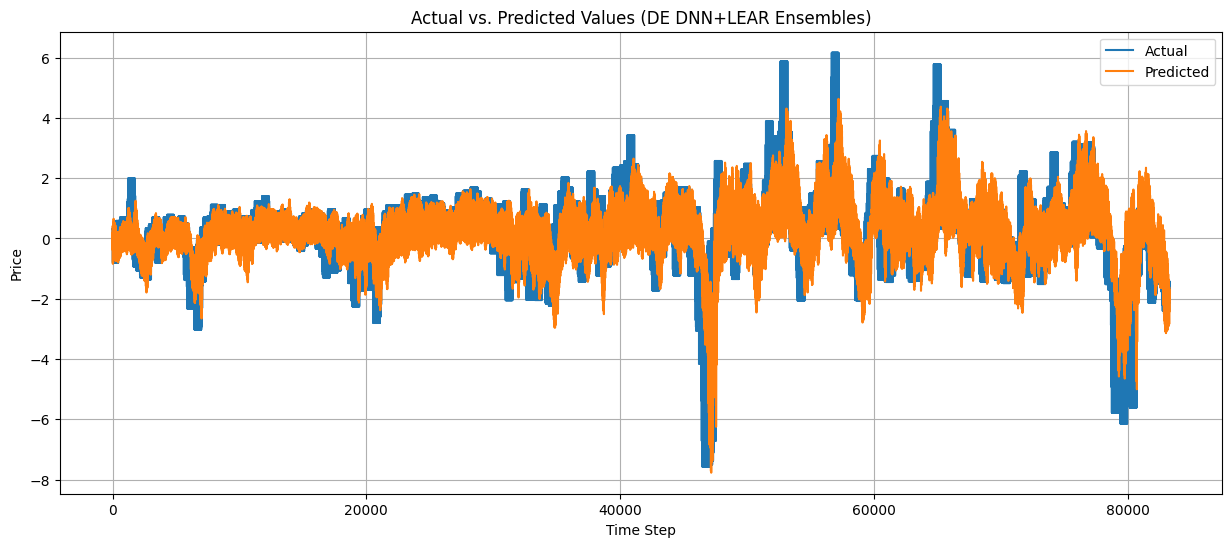

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

# The 'setting_ensemble' variable is already defined in the kernel state from the previous run

# Construct the path to the results directory. The current directory is TimeXer.
# The results folder is at Laksegate-master-thesis/results.
results_dir = os.path.join('./results', setting_ensemble)

# Load true and predicted values
true_values = np.load(os.path.join(results_dir, 'true.npy'))
predicted_values = np.load(os.path.join(results_dir, 'pred.npy'))

# The output from Exp_Long_Term_Forecast test method gives (num_test_samples, pred_len, c_out)
# c_out=1, so we take index 0 of the last axis (Real price predictions)

true_flat = true_values[:, :, 0].reshape(-1)
predicted_flat = predicted_values[:, :, 0].reshape(-1)

# Turn off interactive mode to prevent potential double-display issues
plt.ioff()

fig = plt.figure(figsize=(15, 6))
plt.plot(true_flat, label='Actual')
plt.plot(predicted_flat, label='Predicted')
plt.title('Actual vs. Predicted Values (DE DNN+LEAR Ensembles)')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Explicitly display the figure object
display(fig)

# Close the figure to free up memory after displaying
plt.close(fig)
